# 방약합편 처방 벡터 분석 (Phase 0)

**데이터**: `formulas_bangyak.json` (上統 122 / 中統 178 / 下統 162 = 총 462개)  
**분석 내용**:
1. 데이터 로드 및 기초 통계
2. 처방-약재 행렬 F 구성
3. 처방 간 코사인 유사도 (통별 히트맵)
4. 증상 키워드 분포
5. 유사 처방 검색 예시

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 설정
for fname in fm.findSystemFonts():
    if any(k in fname for k in ['Malgun', 'malgun', 'NanumGothic', 'AppleGothic']):
        matplotlib.rc('font', family=fm.FontProperties(fname=fname).get_name())
        break
matplotlib.rcParams['axes.unicode_minus'] = False

BASE = Path('..').resolve()
DATA = BASE / 'data' / 'formulas_bangyak.json'

with open(DATA, encoding='utf-8') as f:
    raw = json.load(f)

print(f'처방 수: {len(raw)}개')

처방 수: 462개


## 1. 데이터 로드 및 기초 통계

In [2]:
df = pd.DataFrame(raw).set_index('formula_id')

# 통 구분 컬럼 추가
section_map = {'U': '上統', 'M': '中統', 'L': '下統'}
df['section'] = df.index.map(lambda x: section_map.get(x.split('_')[1], '?'))

print('=== 통별 처방 수 ===')
print(df['section'].value_counts().to_string())
print()
print('=== 처방당 약재 수 (기초 통계) ===')
df['herb_count'] = df['composition'].apply(len)
print(df.groupby('section')['herb_count'].describe().round(1).to_string())

=== 통별 처방 수 ===
section
中統    178
下統    162
上統    122

=== 처방당 약재 수 (기초 통계) ===
         count  mean  std  min  25%  50%   75%   max
section                                             
上統       122.0   7.5  4.4  0.0  4.0  7.0  11.0  21.0
下統       162.0   7.0  4.4  0.0  4.0  7.0  10.0  26.0
中統       178.0   6.9  4.7  0.0  3.0  7.0  10.0  28.0


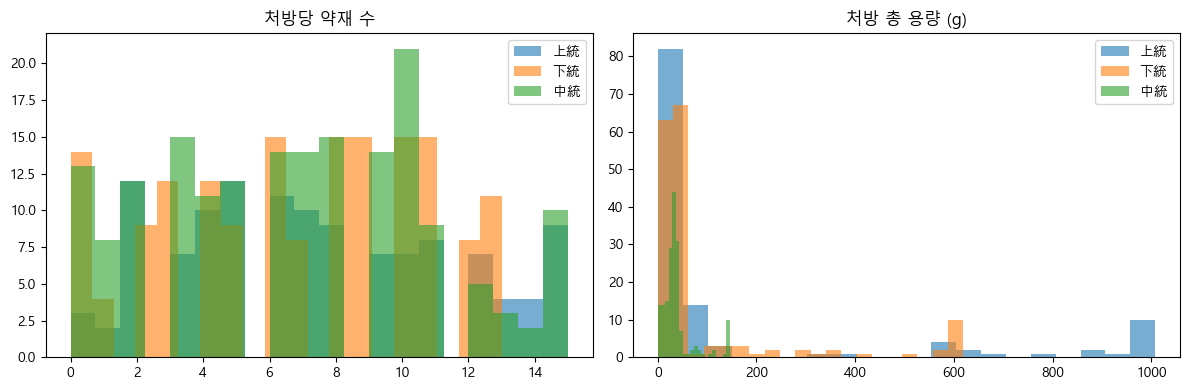

In [3]:
# 총량 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in [
    (axes[0], 'herb_count', '처방당 약재 수'),
    (axes[1], 'total_dose_g', '처방 총 용량 (g)'),
]:
    for sec, grp in df.groupby('section'):
        ax.hist(grp[col].clip(upper=grp[col].quantile(0.95)),
                alpha=0.6, bins=20, label=sec)
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

## 2. 처방-약재 행렬 F

In [4]:
def build_F(df_subset):
    """처방-약재 행렬 (행=처방, 열=약재한자명, 값=dose_ratio)"""
    rows = []
    for fid, row in df_subset.iterrows():
        for herb in row['composition']:
            rows.append({'formula_id': fid,
                         'herb': herb['name_cn'],
                         'ratio': herb['dose_ratio']})
    if not rows:
        return pd.DataFrame()
    long = pd.DataFrame(rows)
    F = long.pivot_table(index='formula_id', columns='herb',
                         values='ratio', fill_value=0)
    return F

F_all = build_F(df)
print(f'F 행렬 크기: {F_all.shape}  (처방 × 약재)')

# 출현 빈도 상위 약재
herb_freq = (F_all > 0).sum().sort_values(ascending=False)
print('\n출현 빈도 TOP 20 약재:')
print(herb_freq.head(20).to_string())

F 행렬 크기: (432, 324)  (처방 × 약재)

출현 빈도 TOP 20 약재:
herb
甘草     215
當歸     135
陳皮     121
人蔘     113
白朮     109
川芎      88
白芍藥     83
白茯苓     82
半夏      76
赤茯苓     56
蒼朮      52
厚朴      52
熟地黃     49
防風      49
黃芩      44
黃芪      42
桔梗      41
香附子     38
枳殼      38
乾薑      37


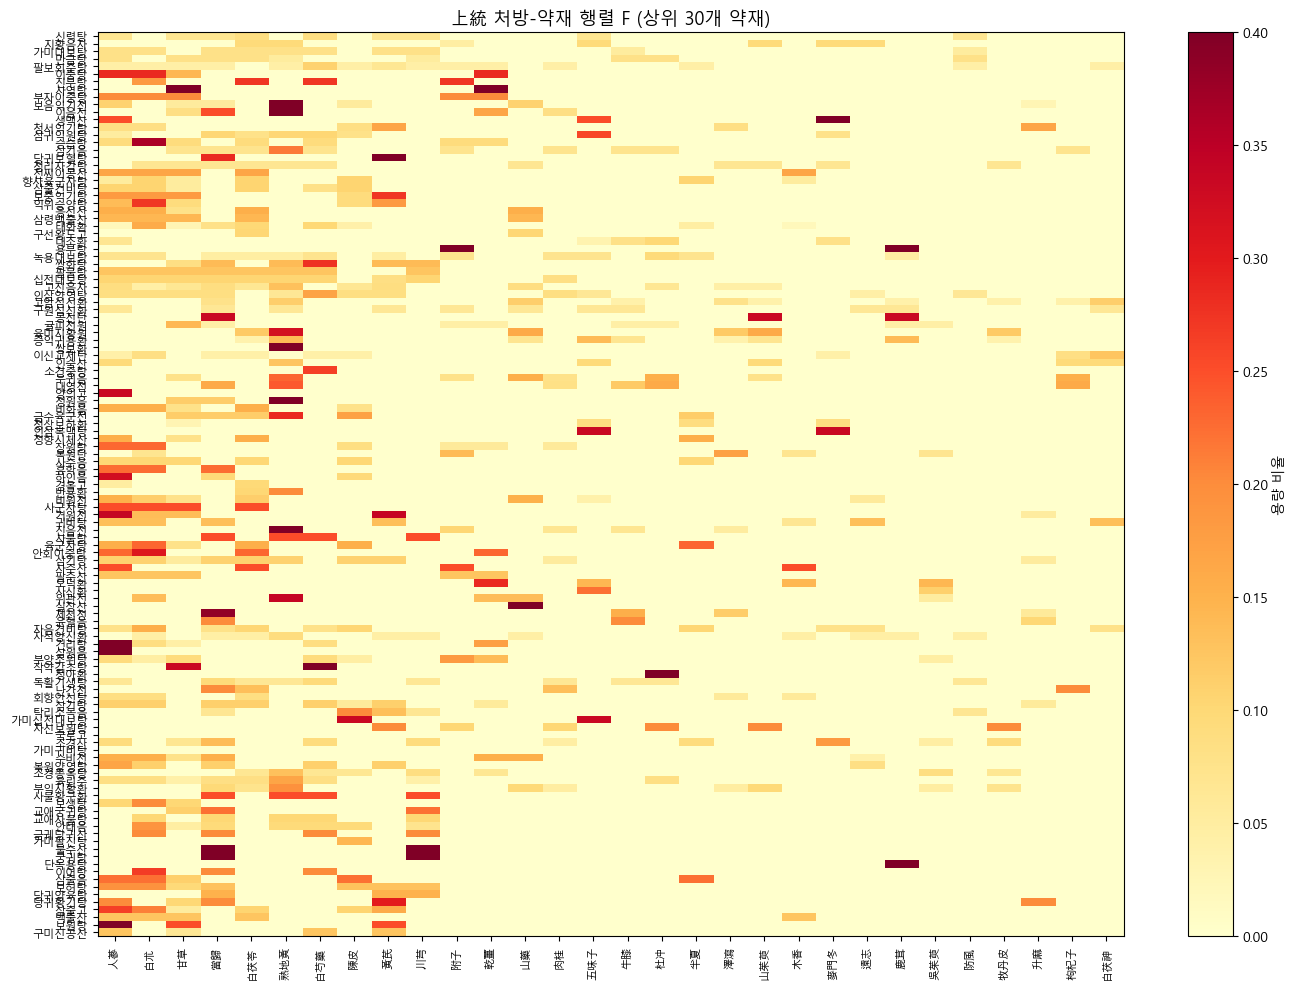

In [5]:
# 상위 30개 약재 × 처방 히트맵 (上統)
df_top = df[df['section'] == '上統']
F_top = build_F(df_top)

top_herbs = (F_top > 0).sum().sort_values(ascending=False).head(30).index
F_show = F_top[top_herbs]

# 처방 이름으로 인덱스 교체
name_map = df['name_kr'].to_dict()
F_show.index = [name_map.get(i, i) for i in F_show.index]

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(F_show.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.4)
ax.set_xticks(range(len(F_show.columns)))
ax.set_xticklabels(F_show.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(F_show.index)))
ax.set_yticklabels(F_show.index, fontsize=8)
plt.colorbar(im, ax=ax, label='용량 비율')
ax.set_title('上統 처방-약재 행렬 F (상위 30개 약재)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. 처방 간 코사인 유사도

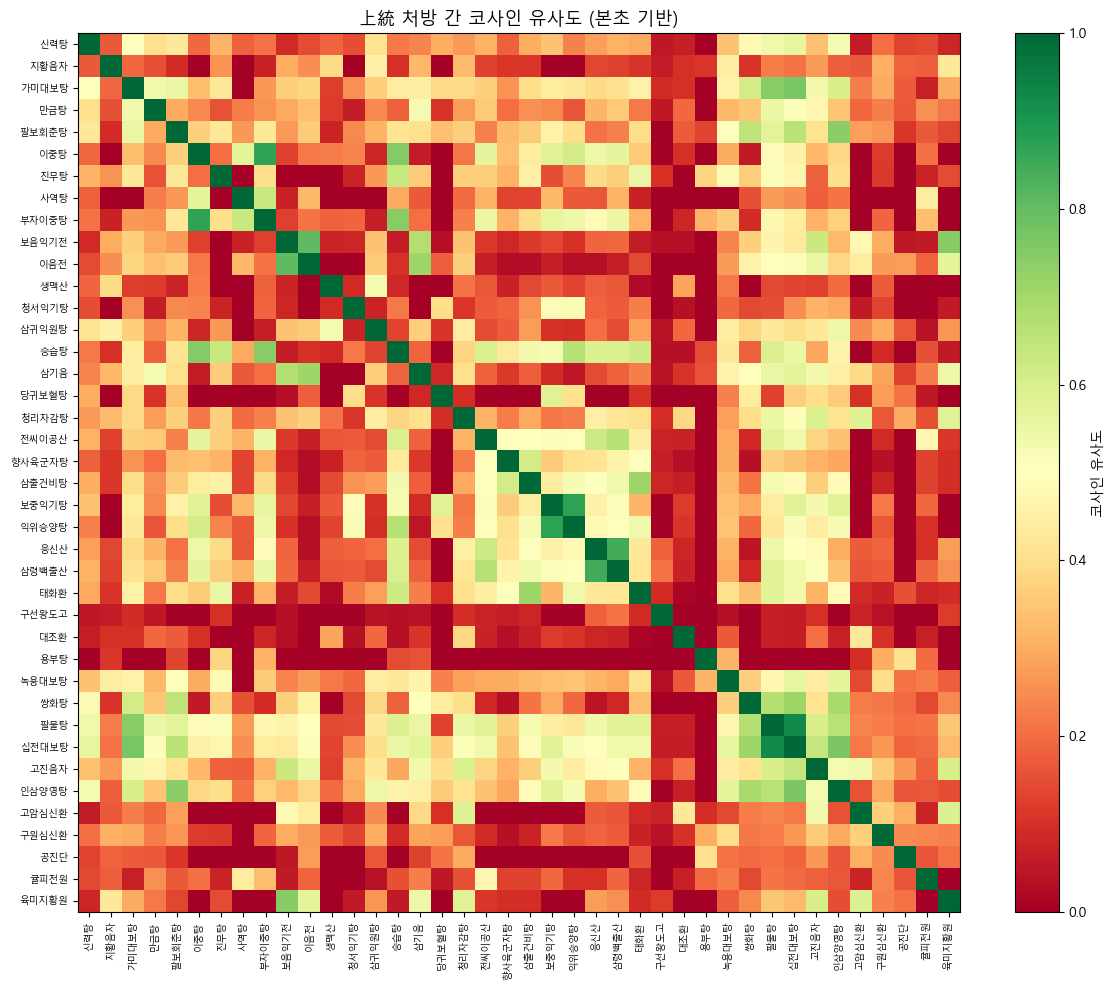

In [6]:
def cosine_sim(F):
    normed = normalize(F.values, norm='l2')
    sim = normed @ normed.T
    return pd.DataFrame(sim, index=F.index, columns=F.index)


def plot_sim_heatmap(sim_df, name_map, title, max_n=40):
    """유사도 히트맵. 처방 수가 많으면 앞 max_n개만 표시."""
    sub = sim_df.iloc[:max_n, :max_n]
    labels = [name_map.get(i, i) for i in sub.index]

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(sub.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax, label='코사인 유사도')
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# 上統 유사도
sim_U = cosine_sim(F_top)
plot_sim_heatmap(sim_U, name_map, '上統 처방 간 코사인 유사도 (본초 기반)', max_n=40)

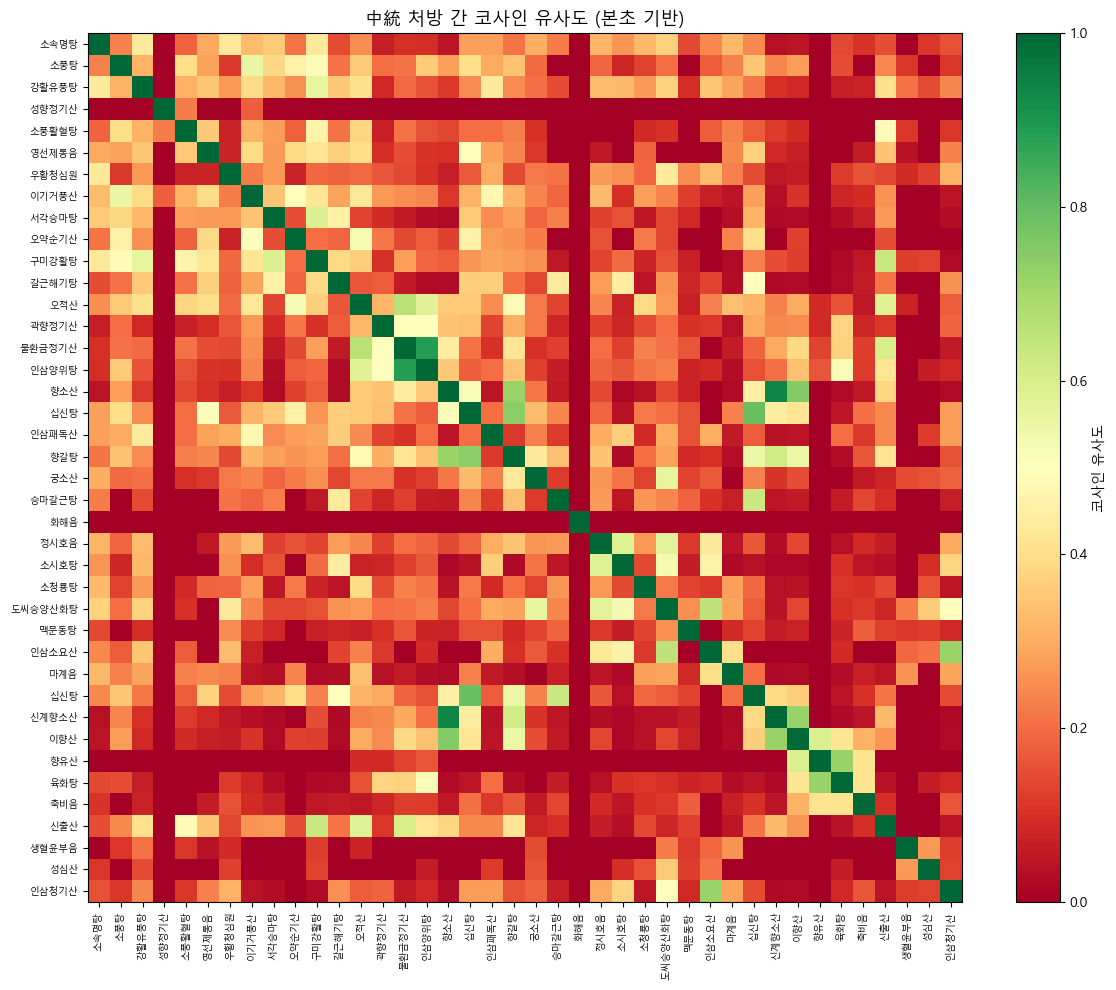

In [7]:
# 中統 유사도
df_mid = df[df['section'] == '中統']
F_mid = build_F(df_mid)
sim_M = cosine_sim(F_mid)
plot_sim_heatmap(sim_M, name_map, '中統 처방 간 코사인 유사도 (본초 기반)', max_n=40)

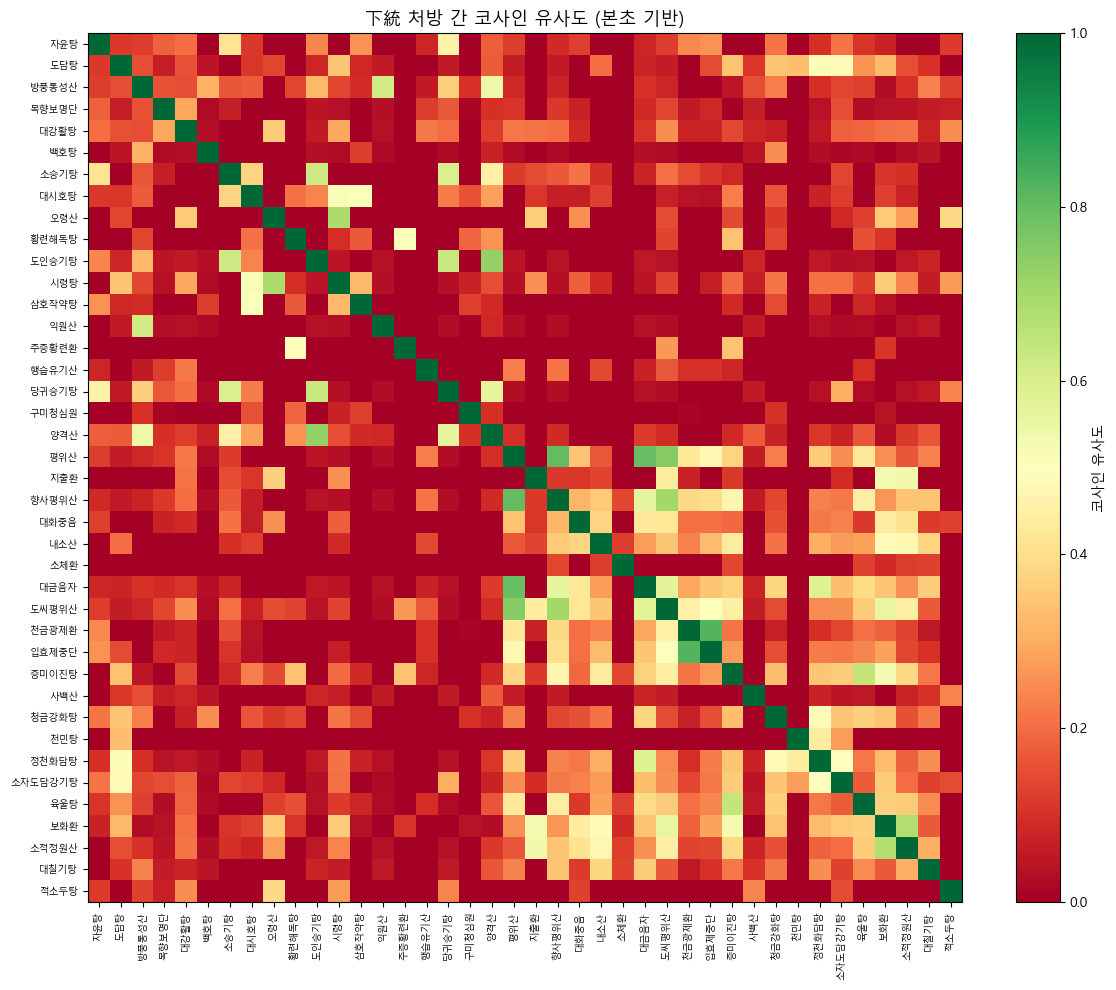

In [8]:
# 下統 유사도
df_low = df[df['section'] == '下統']
F_low = build_F(df_low)
sim_L = cosine_sim(F_low)
plot_sim_heatmap(sim_L, name_map, '下統 처방 간 코사인 유사도 (본초 기반)', max_n=40)

## 4. 증상 키워드 분포

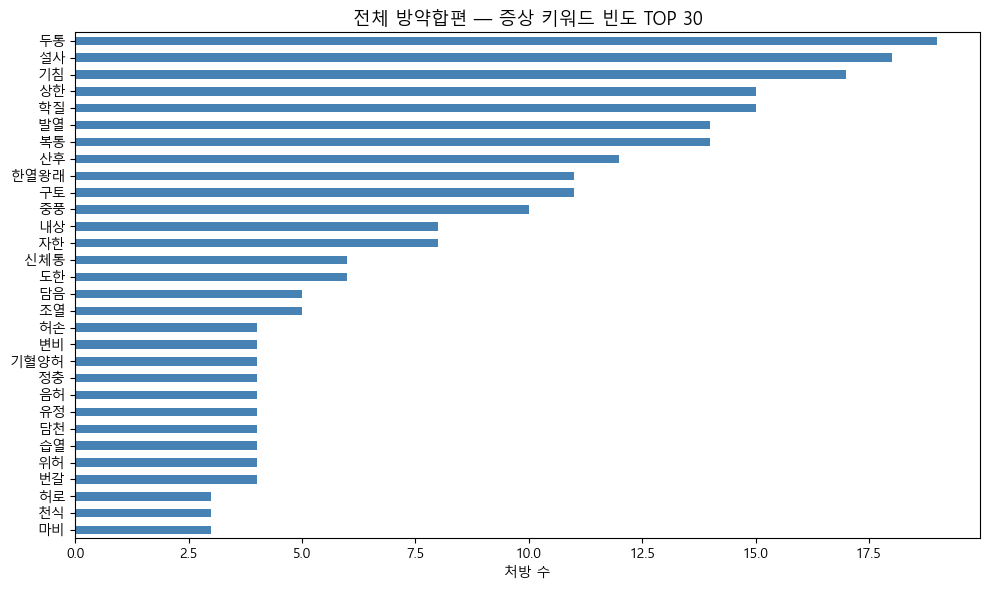

In [9]:
from collections import Counter

# 전체 증상 키워드 빈도
all_symptoms = []
for _, row in df.iterrows():
    all_symptoms.extend(row['indications']['symptoms'])

cnt = Counter(all_symptoms)
top_symp = pd.Series(cnt).sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 6))
top_symp[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('전체 방약합편 — 증상 키워드 빈도 TOP 30', fontsize=13)
ax.set_xlabel('처방 수')
plt.tight_layout()
plt.show()

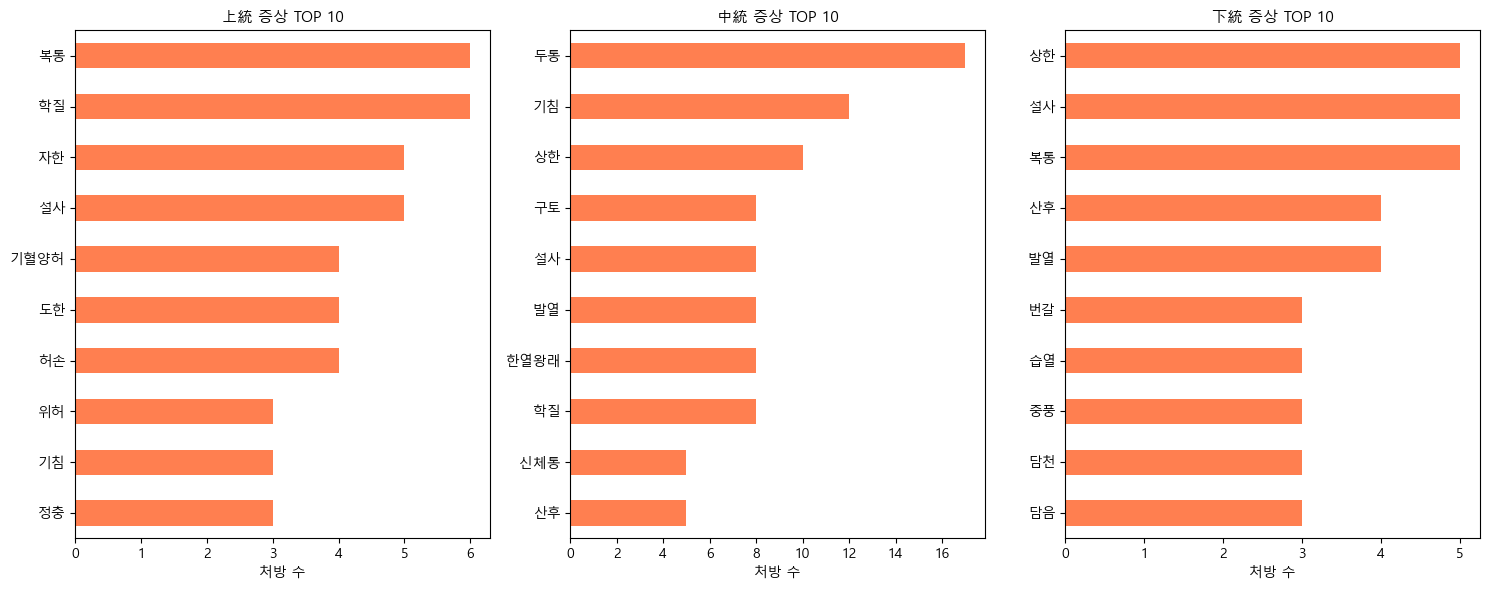

In [10]:
# 통별 TOP 10 증상 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, sec in zip(axes, ['上統', '中統', '下統']):
    syms = []
    for _, row in df[df['section'] == sec].iterrows():
        syms.extend(row['indications']['symptoms'])
    top = pd.Series(Counter(syms)).sort_values(ascending=False).head(10)
    top[::-1].plot.barh(ax=ax, color='coral')
    ax.set_title(f'{sec} 증상 TOP 10', fontsize=11)
    ax.set_xlabel('처방 수')

plt.tight_layout()
plt.show()

## 5. 유사 처방 검색

In [11]:
def find_similar(formula_id, F_matrix, df, top_n=10):
    """특정 처방과 유사한 처방 top_n개 반환."""
    if formula_id not in F_matrix.index:
        print(f'{formula_id} 없음')
        return

    normed = normalize(F_matrix.values, norm='l2')
    idx = list(F_matrix.index).index(formula_id)
    scores = normed @ normed[idx]
    result = pd.Series(scores, index=F_matrix.index).sort_values(ascending=False)

    fname = df.loc[formula_id, 'name_kr']
    print(f'[{formula_id}] {fname} 유사 처방:')
    for fid, score in result.head(top_n + 1).items():
        if fid == formula_id:
            continue
        n = df.loc[fid, 'name_kr'] if fid in df.index else fid
        syms = df.loc[fid, 'indications']['symptoms'][:3] if fid in df.index else []
        print(f'  {score:.3f}  [{fid}] {n}  {syms}')


# 예시 1: 上統 기준 — 보중익기탕
# BY_U_ 번호는 텍스트 순서, 목록에서 보중익기탕 찾기
match = df[df['name_kr'] == '보중익기탕']
if not match.empty:
    fid = match.index[0]
    # 해당 통 전체 F 행렬 사용
    sec = df.loc[fid, 'section']
    F_sec = {'上統': F_top, '中統': F_mid, '下統': F_low}.get(sec, F_all)
    find_similar(fid, F_sec, df)
else:
    print('보중익기탕 미수록 — 첫 번째 처방으로 대체')
    find_similar(df.index[0], F_all, df)

[BY_U_022] 보중익기탕 유사 처방:
  0.899  [BY_U_065] 거원전  ['혈탈', '혈붕']
  0.875  [BY_U_023] 익위승양탕  ['내상', '혈탈']
  0.814  [BY_U_119] 삼출고  ['산후']
  0.797  [BY_U_116] 보허탕  ['산후']
  0.766  [BY_U_121] 보원탕  ['痘疹이 二~三 일 되어, 根窠는 비록 둥글되 頂陷한 것을 다스린다']
  0.667  [BY_U_118] 당귀황기탕  ['출산후 陰部가 나오는 증세를 다스린다']
  0.651  [BY_U_071] 삼기탕  ['氣虛로는 遺尿를 다스린다']
  0.626  [BY_U_064] 사군자탕  ['眞氣가 허약한 것을 補養하고 氣가 짧고 氣가 적은 것을 치료한다']
  0.607  [BY_U_115] 삼출음  ['孕婦의 轉脬로 인한 尿閉를 다스린다']
  0.581  [BY_U_017] 당귀보혈탕  ['기육발열', '심한 갈증']


In [12]:
# 예시 2: 전체 F 기준 약재 구성 유사도 — 六味地黃湯
match2 = df[df['name_kr'].str.contains('육미')]
print('육미 관련 처방:'); print(match2[['name_kr', 'name_cn', 'section']].to_string())
print()
if not match2.empty:
    find_similar(match2.index[0], F_all, df)

육미 관련 처방:
           name_kr name_cn section
formula_id                        
BY_U_040     육미지황원   六味地黃元      上統
BY_M_140    십육미유기음  十六味流氣飮      中統

[BY_U_040] 육미지황원 유사 처방:
  0.800  [BY_U_103] 부익지황환  ['血虛로 인해 月經이 不調하고, 受胎할 수 없는 것을 다스린다']
  0.749  [BY_U_010] 보음익기전  ['변비', '한열왕래', '음허']
  0.724  [BY_U_067] 진음전  ['음허']
  0.706  [BY_U_049] 정원음  ['기단', '천식']
  0.663  [BY_U_076] 위관전  ['복통', '설사']
  0.649  [BY_U_046] 우귀음  ['양허']
  0.605  [BY_U_034] 고진음자  ['설사', '기혈부족', '자한']
  0.589  [BY_U_036] 고암심신환  ['정충', '도한', '신허유열']
  0.582  [BY_U_018] 청리자감탕  ['도한', '조열', '음허화동']
  0.574  [BY_U_051] 금수육군전  ['기침']


In [13]:
# 예시 3: 증상 키워드로 처방 검색
def search_by_symptom(keyword, top_n=15):
    """증상 키워드가 포함된 처방 목록 반환."""
    results = []
    for fid, row in df.iterrows():
        syms = row["indications"]["symptoms"]
        if any(keyword in s for s in syms):
            results.append({
                "formula_id": fid,
                "name_kr": row["name_kr"],
                "section": row["section"],
                "symptoms": ", ".join(syms[:4]),
            })
    res_df = pd.DataFrame(results)
    print(f"[{keyword}] 관련 처방 {len(res_df)}개:")
    if not res_df.empty:
        print(res_df.to_string(index=False))

search_by_symptom("허로")
print()
search_by_symptom("두통")


[허로] 관련 처방 3개:
formula_id name_kr section       symptoms
  BY_U_030   녹용대보탕      上統     소기, 허로, 허손
  BY_U_045    소건중탕      上統 복통, 허로, 이급, 몽유
  BY_M_041   인삼청기산      中統     허로, 조열, 무한

[두통] 관련 처방 19개:
formula_id name_kr section          symptoms
  BY_M_013     오적산      中統    구토, 설사, 내상, 두통
  BY_M_015  불환금정기산      中統 한열왕래, 신체통, 상한, 두통
  BY_M_016   인삼양위탕      中統   내상, 신체통, 상한, 두통
  BY_M_017     향소산      中統 한열왕래, 신체통, 상한, 상풍
  BY_M_018     십신탕      中統      한열왕래, 두통, 무한
  BY_M_019   인삼패독산      中統    상한, 상풍, 발열, 두통
  BY_M_020     향갈탕      中統          한열왕래, 두통
  BY_M_021     궁소산      中統  한열왕래, 상한, 두통, 기침
  BY_M_024    정시호음      中統        오한, 발열, 두통
  BY_M_034     이향산      中統    구토, 설사, 두통, 발열
  BY_M_038     신출산      中統                두통
  BY_M_113   양혈거풍탕      中統                두통
  BY_M_116   청상견통탕      中統                두통
  BY_M_117   순기화중탕      中統                두통
  BY_M_118   당귀보혈탕      中統                두통
  BY_M_119     궁오산      中統            두통, 산후
  BY_M_120   청상사화탕      中統         